# 🚗 Car Price Prediction — Complete ML Pipeline
**Model:** Random Forest Regressor  
**Dataset:** Car resale prices (cars only, bikes excluded)  
**Target:** `Selling_Price` (in lakhs)

## 1. Imports

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2. Load Dataset

In [2]:
raw_data = """Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
swift,2014,4.6,6.87,42450,Diesel,Dealer,Manual,0
vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
s cross,2015,6.5,8.61,33429,Diesel,Dealer,Manual,0
ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0
alto 800,2017,2.85,3.6,2135,Petrol,Dealer,Manual,0
ciaz,2015,6.85,10.38,51000,Diesel,Dealer,Manual,0
ciaz,2015,7.5,9.94,15000,Petrol,Dealer,Automatic,0
ertiga,2015,6.1,7.71,26000,Petrol,Dealer,Manual,0
dzire,2009,2.25,7.21,77427,Petrol,Dealer,Manual,0
ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
ertiga,2015,7.25,10.79,41678,Diesel,Dealer,Manual,0
ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
wagon r,2015,3.25,5.09,35500,CNG,Dealer,Manual,0
sx4,2010,2.65,7.98,41442,Petrol,Dealer,Manual,0
alto k10,2016,2.85,3.95,25000,Petrol,Dealer,Manual,0
ignis,2017,4.9,5.71,2400,Petrol,Dealer,Manual,0
sx4,2011,4.4,8.01,50000,Petrol,Dealer,Automatic,0
alto k10,2014,2.5,3.46,45280,Petrol,Dealer,Manual,0
wagon r,2013,2.9,4.41,56879,Petrol,Dealer,Manual,0
swift,2011,3,4.99,20000,Petrol,Dealer,Manual,0
swift,2013,4.15,5.87,55138,Petrol,Dealer,Manual,0
swift,2017,6,6.49,16200,Petrol,Individual,Manual,0
alto k10,2010,1.95,3.95,44542,Petrol,Dealer,Manual,0
ciaz,2015,7.45,10.38,45000,Diesel,Dealer,Manual,0
ritz,2012,3.1,5.98,51439,Diesel,Dealer,Manual,0
ritz,2011,2.35,4.89,54200,Petrol,Dealer,Manual,0
swift,2014,4.95,7.49,39000,Diesel,Dealer,Manual,0
ertiga,2014,6,9.95,45000,Diesel,Dealer,Manual,0
dzire,2014,5.5,8.06,45000,Diesel,Dealer,Manual,0
sx4,2011,2.95,7.74,49998,CNG,Dealer,Manual,0
dzire,2015,4.65,7.2,48767,Petrol,Dealer,Manual,0
800,2003,0.35,2.28,127000,Petrol,Individual,Manual,0
alto k10,2016,3,3.76,10079,Petrol,Dealer,Manual,0
sx4,2003,2.25,7.98,62000,Petrol,Dealer,Manual,0
baleno,2016,5.85,7.87,24524,Petrol,Dealer,Automatic,0
alto k10,2014,2.55,3.98,46706,Petrol,Dealer,Manual,0
sx4,2008,1.95,7.15,58000,Petrol,Dealer,Manual,0
dzire,2014,5.5,8.06,45780,Diesel,Dealer,Manual,0
omni,2012,1.25,2.69,50000,Petrol,Dealer,Manual,0
ciaz,2014,7.5,12.04,15000,Petrol,Dealer,Automatic,0
ritz,2013,2.65,4.89,64532,Petrol,Dealer,Manual,0
wagon r,2006,1.05,4.15,65000,Petrol,Dealer,Manual,0
ertiga,2015,5.8,7.71,25870,Petrol,Dealer,Manual,0
ciaz,2017,7.75,9.29,37000,Petrol,Dealer,Automatic,0
fortuner,2012,14.9,30.61,104707,Diesel,Dealer,Automatic,0
fortuner,2015,23,30.61,40000,Diesel,Dealer,Automatic,0
innova,2017,18,19.77,15000,Diesel,Dealer,Automatic,0
fortuner,2013,16,30.61,135000,Diesel,Individual,Automatic,0
innova,2005,2.75,10.21,90000,Petrol,Individual,Manual,0
corolla altis,2009,3.6,15.04,70000,Petrol,Dealer,Automatic,0
etios cross,2015,4.5,7.27,40534,Petrol,Dealer,Manual,0
corolla altis,2010,4.75,18.54,50000,Petrol,Dealer,Manual,0
etios g,2014,4.1,6.8,39485,Petrol,Dealer,Manual,1
fortuner,2014,19.99,35.96,41000,Diesel,Dealer,Automatic,0
corolla altis,2013,6.95,18.61,40001,Petrol,Dealer,Manual,0
etios cross,2015,4.5,7.7,40588,Petrol,Dealer,Manual,0
fortuner,2014,18.75,35.96,78000,Diesel,Dealer,Automatic,0
fortuner,2015,23.5,35.96,47000,Diesel,Dealer,Automatic,0
fortuner,2017,33,36.23,6000,Diesel,Dealer,Automatic,0
etios liva,2014,4.75,6.95,45000,Diesel,Dealer,Manual,0
innova,2017,19.75,23.15,11000,Petrol,Dealer,Automatic,0
fortuner,2010,9.25,20.45,59000,Diesel,Dealer,Manual,0
corolla altis,2011,4.35,13.74,88000,Petrol,Dealer,Manual,0
corolla altis,2016,14.25,20.91,12000,Petrol,Dealer,Manual,0
etios liva,2014,3.95,6.76,71000,Diesel,Dealer,Manual,0
corolla altis,2011,4.5,12.48,45000,Diesel,Dealer,Manual,0
corolla altis,2013,7.45,18.61,56001,Petrol,Dealer,Manual,0
etios liva,2011,2.65,5.71,43000,Petrol,Dealer,Manual,0
etios cross,2014,4.9,8.93,83000,Diesel,Dealer,Manual,0
etios g,2015,3.95,6.8,36000,Petrol,Dealer,Manual,0
corolla altis,2013,5.5,14.68,72000,Petrol,Dealer,Manual,0
corolla,2004,1.5,12.35,135154,Petrol,Dealer,Automatic,0
corolla altis,2010,5.25,22.83,80000,Petrol,Dealer,Automatic,0
fortuner,2012,14.5,30.61,89000,Diesel,Dealer,Automatic,0
corolla altis,2016,14.73,14.89,23000,Diesel,Dealer,Manual,0
etios gd,2015,4.75,7.85,40000,Diesel,Dealer,Manual,0
innova,2017,23,25.39,15000,Diesel,Dealer,Automatic,0
innova,2015,12.5,13.46,38000,Diesel,Dealer,Manual,0
innova,2005,3.49,13.46,197176,Diesel,Dealer,Manual,0
camry,2006,2.5,23.73,142000,Petrol,Individual,Automatic,3
land cruiser,2010,35,92.6,78000,Diesel,Dealer,Manual,0
corolla altis,2012,5.9,13.74,56000,Petrol,Dealer,Manual,0
etios liva,2013,3.45,6.05,47000,Petrol,Dealer,Manual,0
etios g,2014,4.75,6.76,40000,Petrol,Dealer,Manual,0
corolla altis,2009,3.8,18.61,62000,Petrol,Dealer,Manual,0
innova,2014,11.25,16.09,58242,Diesel,Dealer,Manual,0
innova,2005,3.51,13.7,75000,Petrol,Dealer,Manual,0
fortuner,2015,23,30.61,40000,Diesel,Dealer,Automatic,0
corolla altis,2008,4,22.78,89000,Petrol,Dealer,Automatic,0
corolla altis,2012,5.85,18.61,72000,Petrol,Dealer,Manual,0
innova,2016,20.75,25.39,29000,Diesel,Dealer,Automatic,0
corolla altis,2017,17,18.64,8700,Petrol,Dealer,Manual,0
corolla altis,2013,7.05,18.61,45000,Petrol,Dealer,Manual,0
fortuner,2010,9.65,20.45,50024,Diesel,Dealer,Manual,0
i20,2010,3.25,6.79,58000,Diesel,Dealer,Manual,1
grand i10,2015,4.4,5.7,28200,Petrol,Dealer,Manual,0
i10,2011,2.95,4.6,53460,Petrol,Dealer,Manual,0
eon,2015,2.75,4.43,28282,Petrol,Dealer,Manual,0
grand i10,2016,5.25,5.7,3493,Petrol,Dealer,Manual,1
xcent,2017,5.75,7.13,12479,Petrol,Dealer,Manual,0
grand i10,2015,5.15,5.7,34797,Petrol,Dealer,Automatic,0
i20,2017,7.9,8.1,3435,Petrol,Dealer,Manual,0
grand i10,2015,4.85,5.7,21125,Diesel,Dealer,Manual,0
i10,2012,3.1,4.6,35775,Petrol,Dealer,Manual,0
elantra,2015,11.75,14.79,43535,Diesel,Dealer,Manual,0
creta,2016,11.25,13.6,22671,Petrol,Dealer,Manual,0
i20,2011,2.9,6.79,31604,Petrol,Dealer,Manual,0
grand i10,2017,5.25,5.7,20114,Petrol,Dealer,Manual,0
verna,2012,4.5,9.4,36100,Petrol,Dealer,Manual,0
eon,2016,2.9,4.43,12500,Petrol,Dealer,Manual,0
eon,2016,3.15,4.43,15000,Petrol,Dealer,Manual,0
verna,2014,6.45,8.4,45078,Petrol,Dealer,Manual,0
verna,2012,4.5,9.4,36000,Petrol,Dealer,Manual,0
eon,2017,3.5,5.43,38488,Petrol,Dealer,Manual,0
i20,2013,4.5,6.79,32000,Petrol,Dealer,Automatic,0
i20,2014,6,7.6,77632,Diesel,Dealer,Manual,0
verna,2015,8.25,9.4,61381,Diesel,Dealer,Manual,0
verna,2013,5.11,9.4,36198,Petrol,Dealer,Automatic,0
i10,2011,2.7,4.6,22517,Petrol,Dealer,Manual,0
grand i10,2015,5.25,5.7,24678,Petrol,Dealer,Manual,0
i10,2011,2.55,4.43,57000,Petrol,Dealer,Manual,0
verna,2012,4.95,9.4,60000,Diesel,Dealer,Manual,0
i20,2012,3.1,6.79,52132,Diesel,Dealer,Manual,0
verna,2013,6.15,9.4,45000,Diesel,Dealer,Manual,0
verna,2017,9.25,9.4,15001,Petrol,Dealer,Manual,0
elantra,2015,11.45,14.79,12900,Petrol,Dealer,Automatic,0
grand i10,2013,3.9,5.7,53000,Diesel,Dealer,Manual,0
grand i10,2015,5.5,5.7,4492,Petrol,Dealer,Manual,0
verna,2017,9.1,9.4,15141,Petrol,Dealer,Manual,0
eon,2016,3.1,4.43,11849,Petrol,Dealer,Manual,0
creta,2015,11.25,13.6,68000,Diesel,Dealer,Manual,0
verna,2013,4.8,9.4,60241,Petrol,Dealer,Manual,0
eon,2012,2,4.43,23709,Petrol,Dealer,Manual,0
verna,2012,5.35,9.4,32322,Diesel,Dealer,Manual,0
xcent,2015,4.75,7.13,35866,Petrol,Dealer,Manual,1
xcent,2014,4.4,7.13,34000,Petrol,Dealer,Manual,0
i20,2016,6.25,7.6,7000,Petrol,Dealer,Manual,0
verna,2013,5.95,9.4,49000,Diesel,Dealer,Manual,0
verna,2012,5.2,9.4,71000,Diesel,Dealer,Manual,0
i20,2012,3.75,6.79,35000,Petrol,Dealer,Manual,0
verna,2015,5.95,9.4,36000,Petrol,Dealer,Manual,0
i10,2013,4,4.6,30000,Petrol,Dealer,Manual,0
i20,2016,5.25,7.6,17000,Petrol,Dealer,Manual,0
creta,2016,12.9,13.6,35934,Diesel,Dealer,Manual,0
city,2013,5,9.9,56701,Petrol,Dealer,Manual,0
brio,2015,5.4,6.82,31427,Petrol,Dealer,Automatic,0
city,2014,7.2,9.9,48000,Diesel,Dealer,Manual,0
city,2013,5.25,9.9,54242,Petrol,Dealer,Manual,0
brio,2012,3,5.35,53675,Petrol,Dealer,Manual,0
city,2016,10.25,13.6,49562,Petrol,Dealer,Manual,0
city,2015,8.5,13.6,40324,Petrol,Dealer,Manual,0
city,2015,8.4,13.6,25000,Petrol,Dealer,Manual,0
amaze,2014,3.9,7,36054,Petrol,Dealer,Manual,0
city,2016,9.15,13.6,29223,Petrol,Dealer,Manual,0
brio,2016,5.5,5.97,5600,Petrol,Dealer,Manual,0
amaze,2015,4,5.8,40023,Petrol,Dealer,Manual,0
jazz,2016,6.6,7.7,16002,Petrol,Dealer,Manual,0
amaze,2015,4,7,40026,Petrol,Dealer,Manual,0
jazz,2017,6.5,8.7,21200,Petrol,Dealer,Manual,0
amaze,2014,3.65,7,35000,Petrol,Dealer,Manual,0
city,2016,8.35,9.4,19434,Diesel,Dealer,Manual,0
brio,2017,4.8,5.8,19000,Petrol,Dealer,Manual,0
city,2015,6.7,10,18828,Petrol,Dealer,Manual,0
city,2011,4.1,10,69341,Petrol,Dealer,Manual,0
city,2009,3,10,69562,Petrol,Dealer,Manual,0
city,2015,7.5,10,27600,Petrol,Dealer,Manual,0
jazz,2010,2.25,7.5,61203,Petrol,Dealer,Manual,0
brio,2014,5.3,6.8,16500,Petrol,Dealer,Manual,0
city,2016,10.9,13.6,30753,Petrol,Dealer,Automatic,0
city,2015,8.65,13.6,24800,Petrol,Dealer,Manual,0
city,2015,9.7,13.6,21780,Petrol,Dealer,Manual,0
jazz,2016,6,8.4,4000,Petrol,Dealer,Manual,0
city,2014,6.25,13.6,40126,Petrol,Dealer,Manual,0
brio,2015,5.25,5.9,14465,Petrol,Dealer,Manual,0
city,2006,2.1,7.6,50456,Petrol,Dealer,Manual,0
city,2014,8.25,14,63000,Diesel,Dealer,Manual,0
city,2016,8.99,11.8,9010,Petrol,Dealer,Manual,0
brio,2013,3.5,5.9,9800,Petrol,Dealer,Manual,0
jazz,2016,7.4,8.5,15059,Petrol,Dealer,Automatic,0
jazz,2016,5.65,7.9,28569,Petrol,Dealer,Manual,0
amaze,2015,5.75,7.5,44000,Petrol,Dealer,Automatic,0
city,2015,8.4,13.6,34000,Petrol,Dealer,Manual,0
city,2016,10.11,13.6,10980,Petrol,Dealer,Manual,0
amaze,2014,4.5,6.4,19000,Petrol,Dealer,Manual,0
brio,2015,5.4,6.1,31427,Petrol,Dealer,Manual,0
jazz,2016,6.4,8.4,12000,Petrol,Dealer,Manual,0
city,2010,3.25,9.9,38000,Petrol,Dealer,Manual,0
amaze,2014,3.75,6.8,33019,Petrol,Dealer,Manual,0
city,2015,8.55,13.09,60076,Diesel,Dealer,Manual,0
city,2016,9.5,11.6,33988,Diesel,Dealer,Manual,0
brio,2015,4,5.9,60000,Petrol,Dealer,Manual,0
city,2009,3.35,11,87934,Petrol,Dealer,Manual,0
city,2017,11.5,12.5,9000,Diesel,Dealer,Manual,0
brio,2016,5.3,5.9,5464,Petrol,Dealer,Manual,0"""

df_raw = pd.read_csv(io.StringIO(raw_data))
print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()

Raw dataset shape: (200, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Data Cleaning

In [3]:
df = df_raw.copy()

# --- Fix 1: Remove non-breaking spaces in Car_Name ---
df['Car_Name'] = df['Car_Name'].str.replace('\xa0', ' ', regex=False).str.strip()

# --- Fix 2: Check and handle missing values ---
print("Missing values per column:")
print(df.isnull().sum())

# --- Fix 3: Outlier detection — flag suspiciously high Driven_kms ---
outlier_threshold = 300000
outliers = df[df['Driven_kms'] > outlier_threshold]
print(f"\nOutliers (Driven_kms > {outlier_threshold:,}):")
print(outliers[['Car_Name', 'Year', 'Driven_kms', 'Selling_Price']])

# Remove extreme outlier (500,000 km Activa — likely data entry error)
df = df[df['Driven_kms'] <= outlier_threshold].reset_index(drop=True)
print(f"\nDataset shape after outlier removal: {df.shape}")

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Outliers (Driven_kms > 300,000):
Empty DataFrame
Columns: [Car_Name, Year, Driven_kms, Selling_Price]
Index: []

Dataset shape after outlier removal: (200, 9)


## 4. Feature Engineering

In [4]:
# Dynamic current year — no hardcoding
current_year = datetime.now().year
print(f"Using current year: {current_year}")

# Car_Age is more meaningful than raw Year
df['Car_Age'] = current_year - df['Year']

# Price depreciation ratio — how much value has been retained
df['Price_Depreciation_Ratio'] = df['Selling_Price'] / df['Present_Price']

# Km per year — usage intensity
df['Km_Per_Year'] = df['Driven_kms'] / df['Car_Age'].replace(0, 1)

# Drop columns not useful for modeling
df.drop(columns=['Year', 'Car_Name'], inplace=True)

print(f"\nFinal feature set: {list(df.columns)}")
df.head()

Using current year: 2026

Final feature set: ['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Price_Depreciation_Ratio', 'Km_Per_Year']


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Price_Depreciation_Ratio,Km_Per_Year
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,0.599284,2250.000000
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,0.497904,3307.692308
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,0.736041,766.666667
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,0.686747,346.666667
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,0.669578,3537.500000


## 5. Exploratory Data Analysis (EDA)

In [5]:
print("=== Statistical Summary ===")
print(df.describe().round(2))

print("\n=== Selling_type Distribution ===")
print(df['Selling_type'].value_counts())

print("\n=== Fuel_Type Distribution ===")
print(df['Fuel_Type'].value_counts())

print("\n=== Transmission Distribution ===")
print(df['Transmission'].value_counts())

=== Statistical Summary ===
       Selling_Price  Present_Price  Driven_kms   Owner  Car_Age  \
count         200.00         200.00      200.00  200.00   200.00   
mean            6.69          10.98    41404.88    0.04    12.41   
std             5.15           8.88    27415.81    0.25     2.89   
min             0.35           2.28     2071.00    0.00     8.00   
25%             3.64           6.47    22332.75    0.00    10.00   
50%             5.25           8.45    40000.00    0.00    12.00   
75%             7.56          13.50    53513.75    0.00    14.00   
max            35.00          92.60   197176.00    3.00    23.00   

       Price_Depreciation_Ratio  Km_Per_Year  
count                    200.00       200.00  
mean                       0.63      3174.14  
std                        0.20      1635.99  
min                        0.11       237.22  
25%                        0.52      2110.07  
50%                        0.66      3250.00  
75%                        0.7

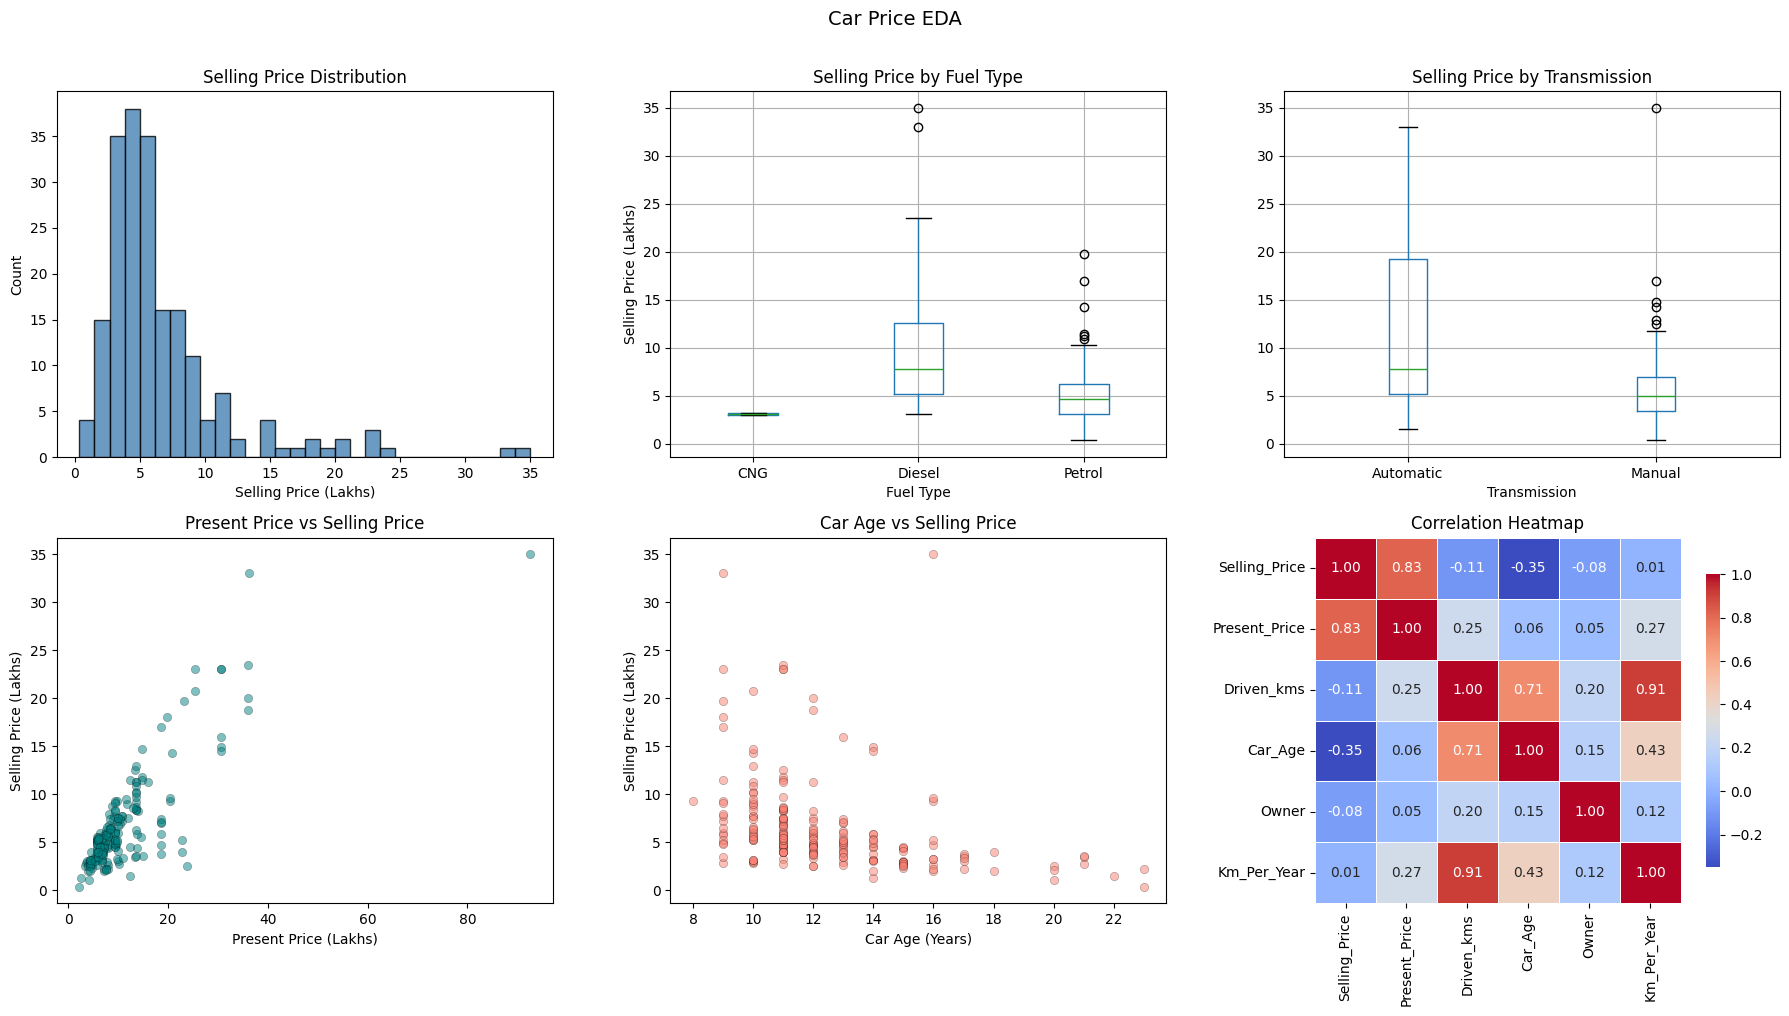

EDA plots saved.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target distribution
axes[0, 0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Selling Price Distribution')
axes[0, 0].set_xlabel('Selling Price (Lakhs)')
axes[0, 0].set_ylabel('Count')

# 2. Selling Price by Fuel Type
df.boxplot(column='Selling_Price', by='Fuel_Type', ax=axes[0, 1])
axes[0, 1].set_title('Selling Price by Fuel Type')
axes[0, 1].set_xlabel('Fuel Type')
axes[0, 1].set_ylabel('Selling Price (Lakhs)')
plt.sca(axes[0, 1])
plt.title('Selling Price by Fuel Type')

# 3. Selling Price by Transmission
df.boxplot(column='Selling_Price', by='Transmission', ax=axes[0, 2])
axes[0, 2].set_title('Selling Price by Transmission')
axes[0, 2].set_xlabel('Transmission')
plt.sca(axes[0, 2])
plt.title('Selling Price by Transmission')

# 4. Present Price vs Selling Price
axes[1, 0].scatter(df['Present_Price'], df['Selling_Price'], alpha=0.5, color='teal', edgecolors='black', linewidths=0.3)
axes[1, 0].set_title('Present Price vs Selling Price')
axes[1, 0].set_xlabel('Present Price (Lakhs)')
axes[1, 0].set_ylabel('Selling Price (Lakhs)')

# 5. Car Age vs Selling Price
axes[1, 1].scatter(df['Car_Age'], df['Selling_Price'], alpha=0.5, color='salmon', edgecolors='black', linewidths=0.3)
axes[1, 1].set_title('Car Age vs Selling Price')
axes[1, 1].set_xlabel('Car Age (Years)')
axes[1, 1].set_ylabel('Selling Price (Lakhs)')

# 6. Correlation Heatmap (numeric features)
num_cols = ['Selling_Price', 'Present_Price', 'Driven_kms', 'Car_Age', 'Owner', 'Km_Per_Year']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2],
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
axes[1, 2].set_title('Correlation Heatmap')

plt.suptitle('Car Price EDA', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved.")

## 6. Data Preparation

In [7]:
# Separate features and target
# Note: Drop Price_Depreciation_Ratio from X — it's derived from Selling_Price (target leakage)
X = df.drop(columns=['Selling_Price', 'Price_Depreciation_Ratio'])
y = df['Selling_Price']

# Feature groups
numeric_features    = ['Present_Price', 'Driven_kms', 'Car_Age', 'Km_Per_Year']
ordinal_features    = ['Owner']          # 0, 1, 2, 3 — treated as ordinal numeric
categorical_features = ['Fuel_Type', 'Selling_type', 'Transmission']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {list(X.columns)}")

Training samples : 160
Test samples     : 40
Features         : ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Km_Per_Year']


## 7. Build Preprocessing + Model Pipeline

In [8]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Owner treated as numeric (ordinal scale: 0 < 1 < 2 < 3)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features + ordinal_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=SEED))
])

print("✅ Pipeline built successfully.")

✅ Pipeline built successfully.


## 8. Cross-Validation (Baseline)

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_r2   = cross_val_score(model_pipeline, X, y, cv=kf, scoring='r2')
cv_mae  = -cross_val_score(model_pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_rmse = np.sqrt(-cross_val_score(model_pipeline, X, y, cv=kf, scoring='neg_mean_squared_error'))

print("=== 5-Fold Cross-Validation (Baseline) ===")
print(f"R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  | Folds: {[round(s,3) for s in cv_r2]}")
print(f"MAE  : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
print(f"RMSE : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

=== 5-Fold Cross-Validation (Baseline) ===
R²   : 0.8714 ± 0.0806  | Folds: [np.float64(0.954), np.float64(0.852), np.float64(0.727), np.float64(0.886), np.float64(0.938)]
MAE  : 0.9446 ± 0.1612
RMSE : 1.7609 ± 0.7272


## 9. Hyperparameter Tuning (GridSearchCV)

In [10]:
param_grid = {
    'regressor__n_estimators':   [100, 200],
    'regressor__max_depth':      [None, 10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf':  [1, 2]
}

grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\n=== Best Hyperparameters ===")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV R²: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== Best Hyperparameters ===
  regressor__max_depth: None
  regressor__min_samples_leaf: 1
  regressor__min_samples_split: 2
  regressor__n_estimators: 100

Best CV R²: 0.8682


## 10. Final Model Evaluation

In [11]:
best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100

print("=" * 45)
print("         FINAL MODEL EVALUATION")
print("=" * 45)
print(f"  R² Score   : {r2:.4f}  (variance explained)")
print(f"  MAE        : {mae:.3f} lakhs")
print(f"  RMSE       : {rmse:.3f} lakhs")
print(f"  MAPE       : {mape:.2f}%")
print(f"  CV R²      : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

         FINAL MODEL EVALUATION
  R² Score   : 0.9612  (variance explained)
  MAE        : 0.699 lakhs
  RMSE       : 0.971 lakhs
  MAPE       : 11.00%
  CV R²      : 0.8714 ± 0.0806


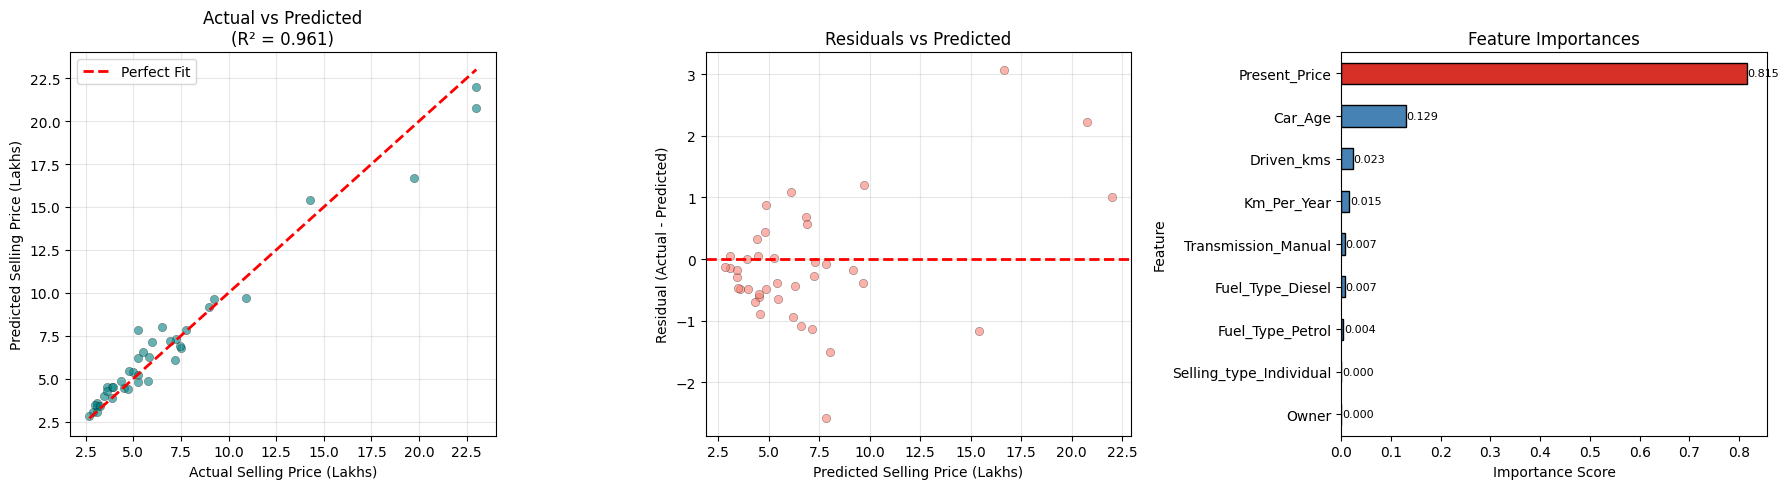

Results plots saved.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolors='black', linewidths=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
axes[0].set_title(f'Actual vs Predicted\n(R² = {r2:.3f})', fontsize=12)
axes[0].set_xlabel('Actual Selling Price (Lakhs)')
axes[0].set_ylabel('Predicted Selling Price (Lakhs)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='salmon', edgecolors='black', linewidths=0.3)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residuals vs Predicted', fontsize=12)
axes[1].set_xlabel('Predicted Selling Price (Lakhs)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].grid(True, alpha=0.3)

# 3. Feature Importances
ohe_names = best_model.named_steps['preprocessor'] \
    .transformers_[1][1].named_steps['onehot'] \
    .get_feature_names_out(categorical_features)
all_feature_names = numeric_features + ordinal_features + list(ohe_names)

fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': best_model.named_steps['regressor'].feature_importances_
}).sort_values('Importance', ascending=True)

colors = ['#d73027' if f == fi_df.iloc[-1]['Feature'] else 'steelblue' for f in fi_df['Feature']]
fi_df.plot(kind='barh', x='Feature', y='Importance', ax=axes[2],
           color=colors, edgecolor='black', legend=False)
axes[2].set_title('Feature Importances', fontsize=12)
axes[2].set_xlabel('Importance Score')
for i, v in enumerate(fi_df['Importance']):
    axes[2].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results plots saved.")

## 11. Feature Importance Summary

In [13]:
fi_df_sorted = fi_df.sort_values('Importance', ascending=False).reset_index(drop=True)
fi_df_sorted.index += 1
fi_df_sorted.index.name = 'Rank'
print(fi_df_sorted.to_string())

                      Feature  Importance
Rank                                     
1               Present_Price    0.814889
2                     Car_Age    0.129408
3                  Driven_kms    0.022669
4                 Km_Per_Year    0.015384
5         Transmission_Manual    0.006789
6            Fuel_Type_Diesel    0.006658
7            Fuel_Type_Petrol    0.003849
8     Selling_type_Individual    0.000265
9                       Owner    0.000090


## 12. Predict on New Data

In [14]:
current_year = datetime.now().year

new_cars = pd.DataFrame({
    'Present_Price': [9.85, 5.59, 30.61],
    'Driven_kms':    [15000, 45000, 80000],
    'Car_Age':       [current_year - 2020, current_year - 2016, current_year - 2015],
    'Km_Per_Year':   [3000, 5625, 10000],
    'Owner':         [0, 1, 0],
    'Fuel_Type':     ['Petrol', 'Petrol', 'Diesel'],
    'Selling_type':  ['Dealer', 'Dealer', 'Individual'],
    'Transmission':  ['Manual', 'Manual', 'Automatic']
})

predictions = best_model.predict(new_cars)

print("=== Predictions on New Cars ===")
for i, pred in enumerate(predictions):
    print(f"Car {i+1}: Predicted Selling Price = ₹ {pred:.2f} Lakhs")

=== Predictions on New Cars ===
Car 1: Predicted Selling Price = ₹ 8.05 Lakhs
Car 2: Predicted Selling Price = ₹ 3.68 Lakhs
Car 3: Predicted Selling Price = ₹ 19.85 Lakhs


## 13. Pipeline Summary

| Step | Detail |
|------|--------|
| Dataset | Cars only (bikes excluded), outliers removed |
| Feature Engineering | Car_Age (dynamic), Km_Per_Year, Depreciation Ratio |
| Data Leakage Prevention | Price_Depreciation_Ratio dropped from X |
| Preprocessing | StandardScaler (numeric) + OHE drop='first' (categorical) |
| Validation | 5-Fold Cross-Validation (R², MAE, RMSE) |
| Tuning | GridSearchCV over 24 hyperparameter combinations |
| Model | RandomForestRegressor (best params) |
| Key Finding | Present_Price and Car_Age are the strongest predictors |